In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder

In [6]:
df = pd.read_csv("house_price_dataset (1).csv")

In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [9]:
X = df.drop(columns=['Price'])   # target column
y = df['Price']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)   # regression output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',    
    loss='mse',
    metrics=['mae']
)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 886256435200.0000 - mae: 721648.6250 - val_loss: 806725287936.0000 - val_mae: 713606.5000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 886255255552.0000 - mae: 721647.8125 - val_loss: 806724042752.0000 - val_mae: 713605.6250
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 886253682688.0000 - mae: 721646.8125 - val_loss: 806722207744.0000 - val_mae: 713604.4375
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 886251520000.0000 - mae: 721645.3750 - val_loss: 806719520768.0000 - val_mae: 713602.6875
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 886248177664.0000 - mae: 721643.1875 - val_loss: 806715523072.0000 - val_mae: 713600.0000
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 886243000320.0000 - mae: 721640.0625 - val_loss: 806709559296.0000 - val_mae: 713596.1250
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 886235332608.0000 - mae: 721635.4375 - val_loss: 8

In [15]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 716537528320.0000 - mae: 685496.5625
Mean Absolute Error: 685496.56


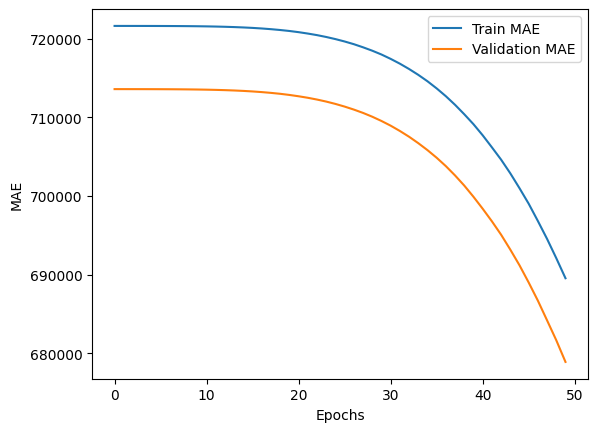

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

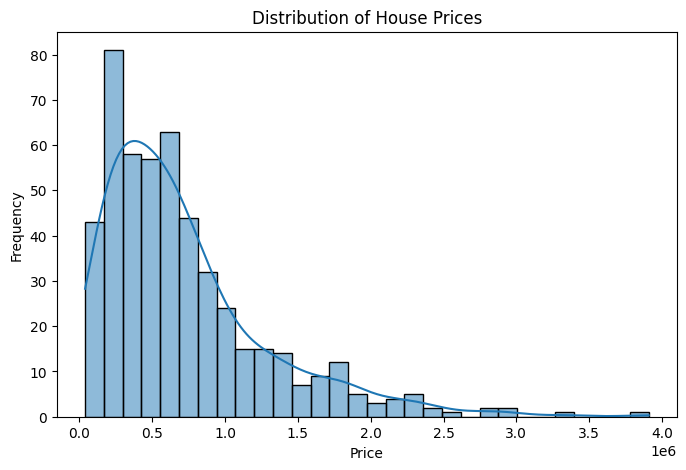

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()